Data Set source : (Customer Datasets)[https://www.kaggle.com/datasets/zohrenotash/customer-datasets?select=Customer+DataSet.csv]

## About Daata columns


| Attribute | Data Type | Description |
| :--- | :--- | :--- |
| **cust_id** | Object | Identification of Credit Card holder (Categorical) |
| **balance** | Float | Total amount of money that you owe to your credit card company |
| **balance_frequency** | Float | How frequently the balance is updated, score between 0 and 1 (1 = frequently updated, 0 = not frequently updated) |
| **purchases** | Float | Amount of purchases made from account (oneoff_PURCHASE+installments_purchases) |
| **oneoff_purchases** | Float | Maximum purchase amount done in one-go |
| **installments_purchases** | Float | Amount of purchase done in installment |
| **cash_advance** | Float | Cash in advance given by the user |
| **purchases_frequency** | Float | How frequently the purchases are being made, score between 0 and 1 (1 = frequently purchased, 0 = not frequently purchased) |
| **oneoff_purchases_frequency** | Float | How frequently purchases are happening in one-go (1 = frequently purchased, 0 = not frequently purchased) |
| **purchases_installments_frequency** | Float | How frequently purchases in installments are being done (1 = frequently done, 0 = not frequently done) |
| **cash_advance_frequency** | Float | How frequently the cash in advance being paid |
| **cash_advance_trx** | Integer | Number of Transactions made with "Cash in Advanced" |
| **purchases_trx** | Integer | Number of purchase transactions made |
| **credit_limit** | Float | Limit of Credit Card for user |
| **payments** | Float | Amount of payment done by user |
| **minimum_payments** | Float | minimum amount of payments made by user |
| **prc_full_payment** | Float | Percent of full payment paid by user |
| **tenure** | Integer | tenure of credit card service for user in years. |


In [84]:
#importing lirarries
import os
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from kneed import KneeLocator
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA


In [4]:
#readd data
dataframe = pd.read_csv("../data/Customer_Dataset.csv")
df = dataframe.copy()

In [5]:
df.sample(7)

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
4727,C14856,28.588826,1.000000,151.92,0.00,151.92,0.000000,1.000000,0.000000,0.875000,0.000000,0,8,1000.0,111.631804,111.312954,0.666667,8
5894,C16060,2643.019532,1.000000,554.38,191.13,363.25,0.000000,1.000000,0.250000,0.916667,0.000000,0,15,8000.0,681.881907,882.049542,0.000000,12
1601,C11654,1191.662907,1.000000,979.92,849.92,130.00,0.000000,0.750000,0.416667,0.416667,0.000000,0,18,4350.0,278.328435,470.064242,0.000000,12
5074,C15217,51.004807,0.909091,431.93,0.00,431.93,0.000000,1.000000,0.000000,1.000000,0.000000,0,17,4000.0,1089.402716,135.208940,0.300000,12
1568,C11621,223.818492,1.000000,1702.42,725.00,977.42,0.000000,0.916667,0.083333,0.833333,0.000000,0,12,7300.0,1913.220366,208.079912,0.250000,12
6946,C17135,673.982097,1.000000,110.00,0.00,110.00,0.000000,0.166667,0.000000,0.166667,0.000000,0,2,1000.0,789.587001,175.328419,0.000000,12
4249,C14367,8040.732429,1.000000,0.00,0.00,0.00,3500.334072,0.000000,0.000000,0.000000,0.333333,21,0,12000.0,2709.478892,2044.554634,0.000000,12


### Inspecting Datatypes and Misssing Values

In [9]:
print("Datatypes : ")
print(df.dtypes)

print("-"*40)
print("Missing Values:")
print(df.isnull().sum()[df.isnull().sum() > 0])


print("-"*40)
print("Duplicte  Values:")
print(df.duplicated().sum())


Datatypes : 
CUST_ID                                 str
BALANCE                             float64
BALANCE_FREQUENCY                   float64
PURCHASES                           float64
ONEOFF_PURCHASES                    float64
INSTALLMENTS_PURCHASES              float64
CASH_ADVANCE                        float64
PURCHASES_FREQUENCY                 float64
ONEOFF_PURCHASES_FREQUENCY          float64
PURCHASES_INSTALLMENTS_FREQUENCY    float64
CASH_ADVANCE_FREQUENCY              float64
CASH_ADVANCE_TRX                      int64
PURCHASES_TRX                         int64
CREDIT_LIMIT                        float64
PAYMENTS                            float64
MINIMUM_PAYMENTS                    float64
PRC_FULL_PAYMENT                    float64
TENURE                                int64
dtype: object
----------------------------------------
Missing Values:
CREDIT_LIMIT          1
MINIMUM_PAYMENTS    313
dtype: int64
----------------------------------------
Duplicte  Values:
0


1. Datatypes: are mostly float and some are integers
2. Missing Values. : credit limit has 1 annd minimum payments has 313 so we have to check this which. kind of null it is
3. No Duplicates


In [13]:
df[df['CREDIT_LIMIT'].isnull()]

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
5203,C15349,18.400472,0.166667,0.0,0.0,0.0,186.853063,0.0,0.0,0.0,0.166667,1,0,NaN,9.040017,14.418723,0.0,6


In [14]:
df[df['MINIMUM_PAYMENTS'].isnull()]

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.0,12
45,C10047,2242.311686,1.000000,437.00,97.00,340.0,184.648692,0.333333,0.083333,0.333333,0.166667,2,5,2400.0,0.000000,NaN,0.0,12
47,C10049,3910.111237,1.000000,0.00,0.00,0.0,1980.873201,0.000000,0.000000,0.000000,0.500000,7,0,4200.0,0.000000,NaN,0.0,12
54,C10056,6.660517,0.636364,310.00,0.00,310.0,0.000000,0.666667,0.000000,0.666667,0.000000,0,8,1000.0,417.016763,NaN,0.0,12
55,C10057,1311.995984,1.000000,1283.90,1283.90,0.0,0.000000,0.250000,0.250000,0.000000,0.000000,0,6,6000.0,0.000000,NaN,0.0,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8919,C19160,14.524779,0.333333,152.00,152.00,0.0,0.000000,0.333333,0.333333,0.000000,0.000000,0,2,1500.0,0.000000,NaN,0.0,6
8929,C19170,371.527312,0.333333,0.00,0.00,0.0,1465.407927,0.000000,0.000000,0.000000,0.166667,5,0,1500.0,0.000000,NaN,0.0,6
8935,C19176,183.817004,1.000000,465.90,0.00,465.9,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1500.0,0.000000,NaN,0.0,6
8944,C19185,193.571722,0.833333,1012.73,1012.73,0.0,0.000000,0.333333,0.333333,0.000000,0.000000,0,2,4000.0,0.000000,NaN,0.0,6


oK so their is one nan value we can impute it easily but first we have to check distriutions so we can impute them accordingly


In [17]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.474828,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.13856
BALANCE_FREQUENCY,8950.0,0.877271,0.236904,0.000000,0.888889,1.000000,1.000000,1.00000
PURCHASES,8950.0,1003.204834,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.57000
ONEOFF_PURCHASES,8950.0,592.437371,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.25000
INSTALLMENTS_PURCHASES,8950.0,411.067645,904.338115,0.000000,0.000000,89.000000,468.637500,22500.00000
CASH_ADVANCE,8950.0,978.871112,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.21176
PURCHASES_FREQUENCY,8950.0,0.490351,0.401371,0.000000,0.083333,0.500000,0.916667,1.00000
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.202458,0.298336,0.000000,0.000000,0.083333,0.300000,1.00000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.364437,0.397448,0.000000,0.000000,0.166667,0.750000,1.00000
CASH_ADVANCE_FREQUENCY,8950.0,0.135144,0.200121,0.000000,0.000000,0.000000,0.222222,1.50000


#### Removing Identifier

In [18]:
df = df.drop(columns=["CUST_ID"])

In [19]:
df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


#### checking the distribution


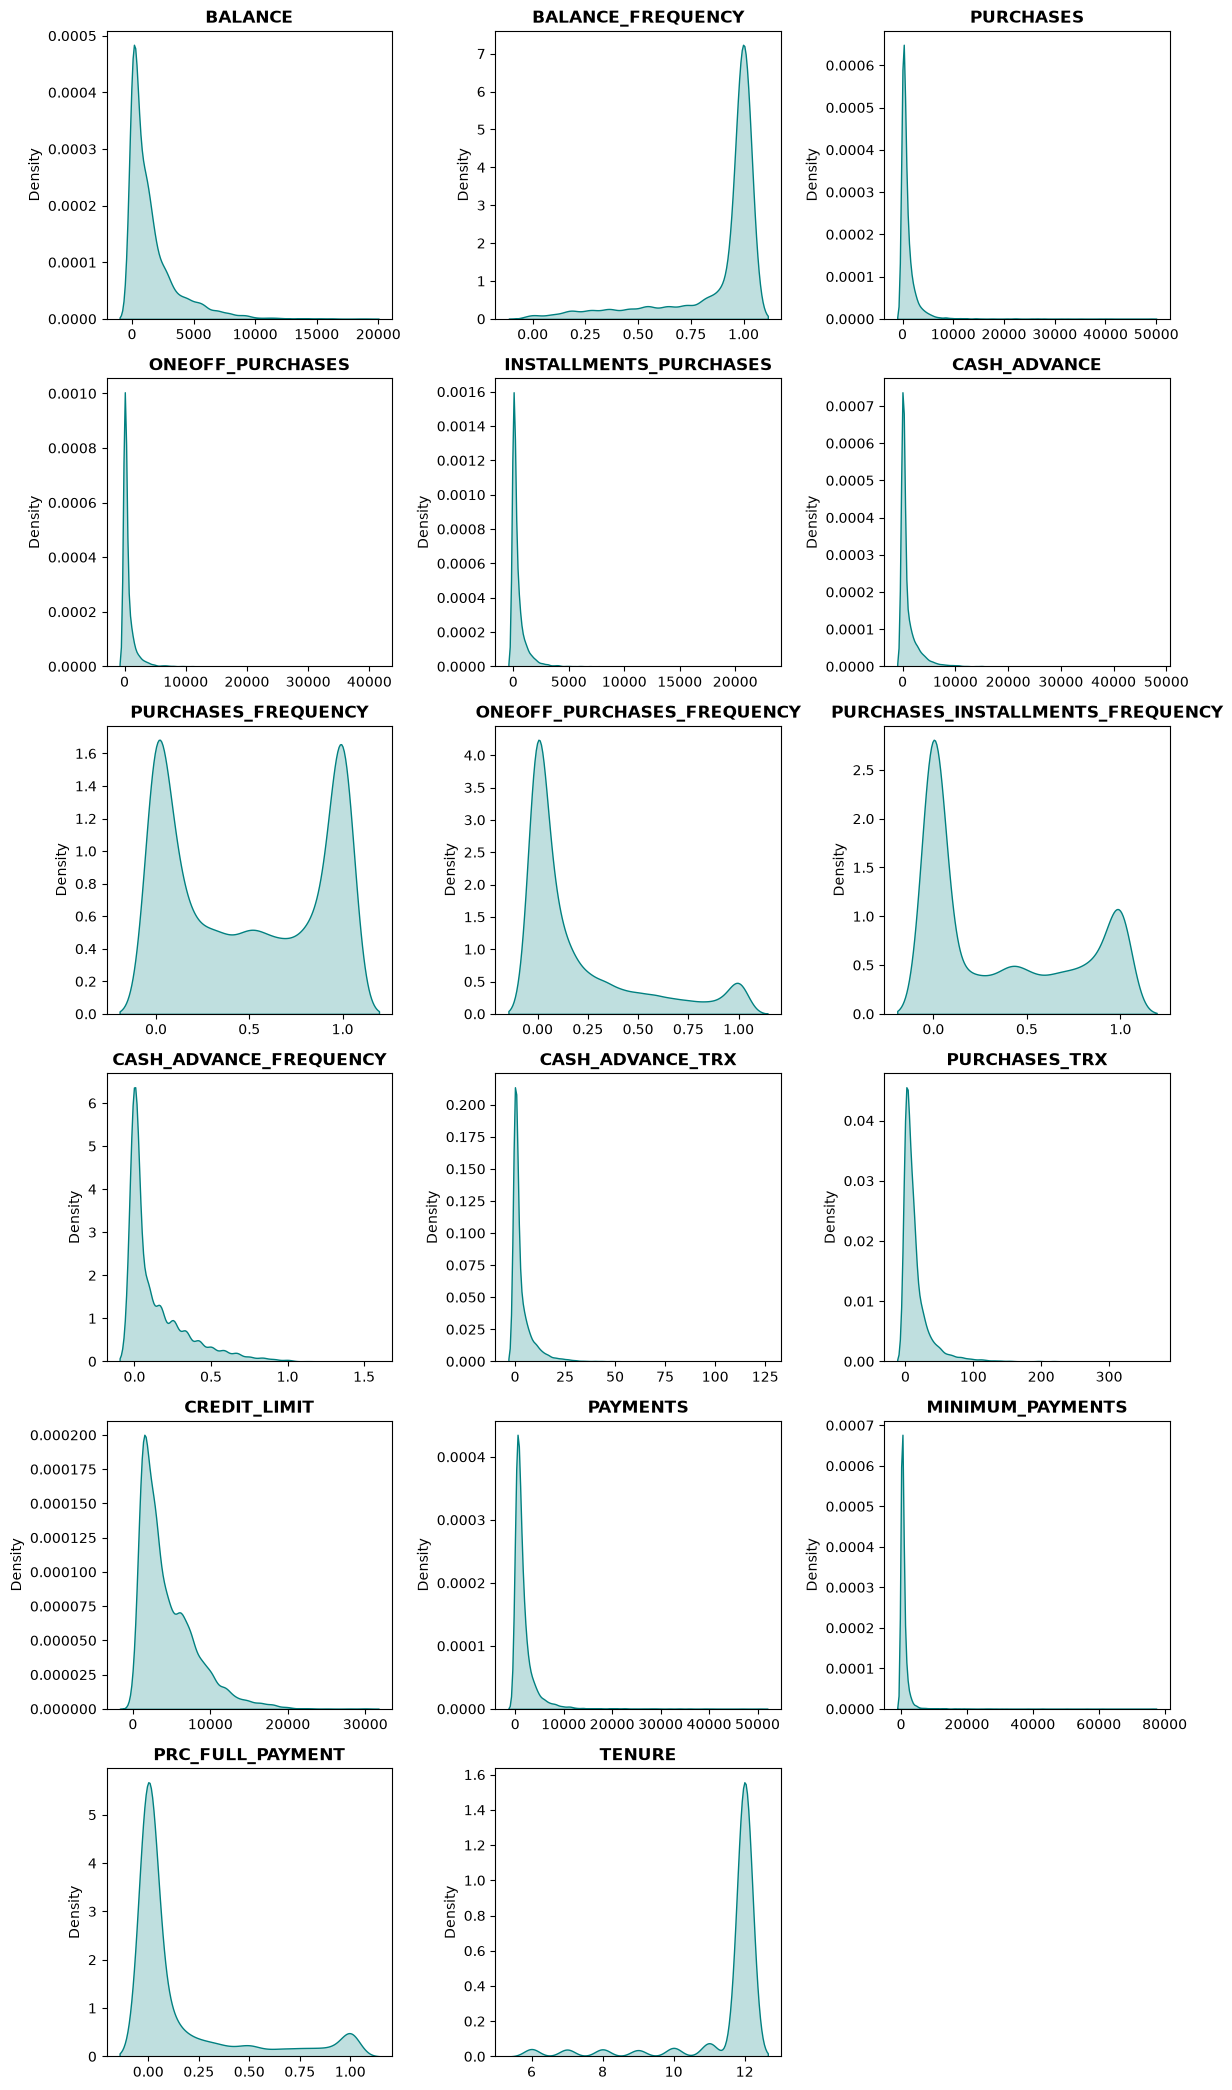

In [ ]:
import math
# 1. Filter for numeric columns only
numeric_cols = df.select_dtypes(include='number').columns
num_features = len(numeric_cols)

# 2. Configure the grid layout (e.g., 3 plots per row)
cols_per_row = 3
rows_required = math.ceil(num_features / cols_per_row)

# 3. Create the figure and axes grid
fig, axes = plt.subplots(
    nrows=rows_required, 
    ncols=cols_per_row, 
    figsize=(cols_per_row * 4, rows_required * 3.5)
)

# 4. Flatten the axes array for easy, single-loop iteration
axes = axes.flatten()

# 5. Loop through columns and plot on designated grid cells
for i, col in enumerate(numeric_cols):
    sns.kdeplot(data=df, x=col, fill=True, ax=axes[i], color="teal")
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')  # Clears redundant x-labels for a cleaner look

# 6. Hide any blank, unused subplots at the end of the grid
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# 7. Adjust spacing and display
plt.tight_layout()
plt.show()


most columns are skewd either left or right skewedd. what it shows :  that data contain outliers  also for missing value hanndling we have to fill it by median as it is  not. affected by outliers


### checking correlation

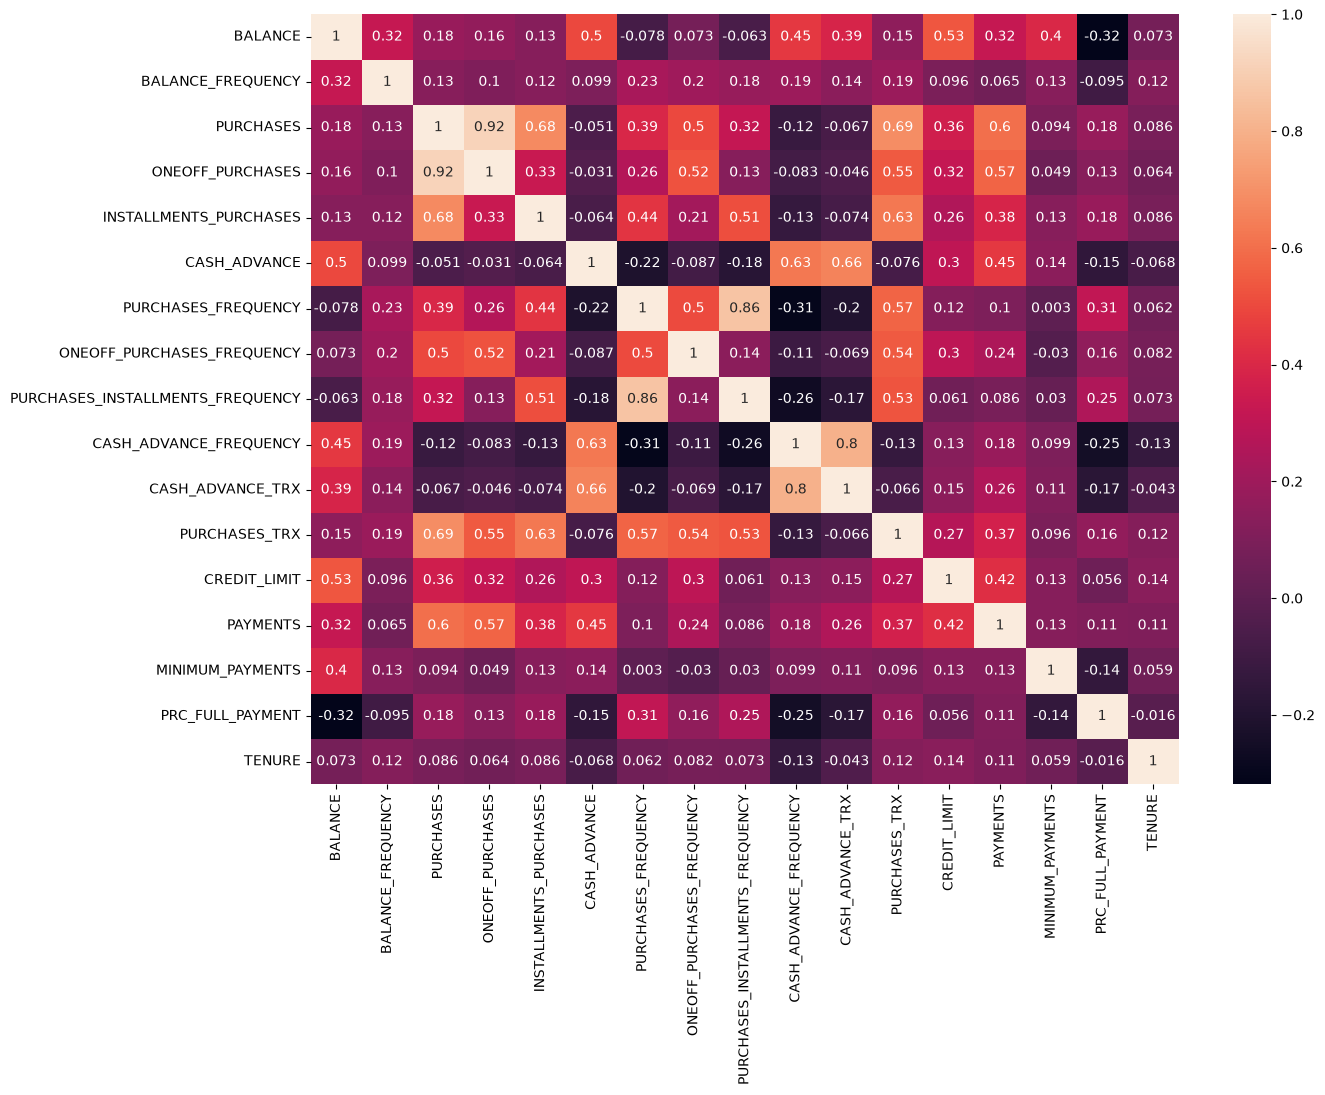

In [29]:
corr_matrix = df.corr()
plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix  , annot=True)
plt.show()

1. purchase installment  frequecy & purchases frequency (keep purchase frequency)

2. on off purchase &   purchases (keep purchases already it have on off purchase and. installemt purchase)

3. cash advamce trx & cash advance frequency (keeping cash advance frequency)

These columns have high positive co relation. amomg them it means if one grows other also grows. so as clustering algorithm like k-means make clusters based on distance two highly co related features will be shown. as thhe same concepet and will be done double  calculation of the same concept. also algorithm will start strecthing alonng . 
so we will keep 1 of them and drop thhe less intitutive one


## Selecting thhe Meaning full columns/ Features

Below are the selected columns for the modeling they differnet enough for meaningfull clusters


| Attribute | Data Type | Description |
| :--- | :--- | :--- |
| **balance** | Float | Total amount of money that you owe to your credit card company |
| **balance_frequency** | Float | How frequently the balance is updated, score between 0 and 1 (1 = frequently updated, 0 = not frequently updated) |
| **purchases** | Float | Amount of purchases made from account (oneoff_PURCHASE+installments_purchases) |
| **cash_advance** | Float | Cash in advance given by the user |
| **purchases_frequency** | Float | How frequently the purchases are being made, score between 0 and 1 (1 = frequently purchased, 0 = not frequently purchased) |
| **cash_advance_frequency** | Float | How frequently the cash in advance being paid |
| **purchases_trx** | Integer | Number of purchase transactions made |
| **credit_limit** | Float | Limit of Credit Card for user |
| **payments** | Float | Amount of payment done by user |
| **prc_full_payment** | Float | Percent of full payment paid by user |
| **tenure** | Integer | tenure of credit card service for user in years. |



these are the columnns that are not included

| Attribute | Data Type | Description |
| :--- | :--- | :--- |
| **oneoff_purchases** | Float | Maximum purchase amount done in one-go |
| **installments_purchases** | Float | Amount of purchase done in installment |
| **purchases_installments_frequency** | Float | How frequently purchases in installments are being done (1 = frequently done, 0 = not frequently done) |
| **cash_advance_trx** | Integer | Number of Transactions made with "Cash in Advanced" |
| **minimum_payments** | Float | minimum amount of payments made by user |
| **prc_full_payment** | Float | Percent of full payment paid by user |
| **oneoff_purchases_frequency** | Float | How frequently purchases are happening in one-go (1 = frequently purchased, 0 = not frequently purchased) |
| **prc_full_payment** | Float | Percent of full payment paid by user |


In [30]:
df.columns

Index(['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES',
       'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY',
       'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY',
       'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX',
       'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT',
       'TENURE'],
      dtype='str')

In [31]:
# filtering out slected features
selected_f = [
    'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', "CASH_ADVANCE",'PURCHASES_FREQUENCY','CASH_ADVANCE_FREQUENCY','PURCHASES_TRX', 'CREDIT_LIMIT', "PAYMENTS",'PRC_FULL_PAYMENT', "TENURE", 
]

cluster_df = df[selected_f].copy()


In [33]:
cluster_df.sample(5)

,BALANCE,BALANCE_FREQUENCY,PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,PRC_FULL_PAYMENT,TENURE
1237,12.408750,0.300000,85.50,0.000000,0.100000,0.000000,1,1500.0,414.010478,0.0,10
2869,4420.693904,1.000000,0.00,3202.933702,0.000000,1.000000,0,4600.0,2831.140832,0.0,12
1604,3391.702180,1.000000,38902.71,0.000000,1.000000,0.000000,195,18000.0,35843.625930,1.0,12
7417,33.880019,0.909091,3421.12,269.619390,0.916667,0.166667,28,3500.0,3977.215235,1.0,12
8944,193.571722,0.833333,1012.73,0.000000,0.333333,0.000000,2,4000.0,0.000000,0.0,6


In [35]:
cluster_df.describe().T

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.474828,2081.531879,0.0,128.281915,873.385231,2054.140036,19043.13856
BALANCE_FREQUENCY,8950.0,0.877271,0.236904,0.0,0.888889,1.000000,1.000000,1.00000
PURCHASES,8950.0,1003.204834,2136.634782,0.0,39.635000,361.280000,1110.130000,49039.57000
CASH_ADVANCE,8950.0,978.871112,2097.163877,0.0,0.000000,0.000000,1113.821139,47137.21176
PURCHASES_FREQUENCY,8950.0,0.490351,0.401371,0.0,0.083333,0.500000,0.916667,1.00000
CASH_ADVANCE_FREQUENCY,8950.0,0.135144,0.200121,0.0,0.000000,0.000000,0.222222,1.50000
PURCHASES_TRX,8950.0,14.709832,24.857649,0.0,1.000000,7.000000,17.000000,358.00000
CREDIT_LIMIT,8949.0,4494.449450,3638.815725,50.0,1600.000000,3000.000000,6500.000000,30000.00000
PAYMENTS,8950.0,1733.143852,2895.063757,0.0,383.276166,856.901546,1901.134317,50721.48336
PRC_FULL_PAYMENT,8950.0,0.153715,0.292499,0.0,0.000000,0.000000,0.142857,1.00000


## Handling Missing Values

In [36]:
cluster_df.isnull().sum()

BALANCE                   0
BALANCE_FREQUENCY         0
PURCHASES                 0
CASH_ADVANCE              0
PURCHASES_FREQUENCY       0
CASH_ADVANCE_FREQUENCY    0
PURCHASES_TRX             0
CREDIT_LIMIT              1
PAYMENTS                  0
PRC_FULL_PAYMENT          0
TENURE                    0
dtype: int64

In [40]:
#only credit limit have one missing value so we impute it median beacuse mediann is robust to outliers or skewed distribution
median = cluster_df["CREDIT_LIMIT"].median()
cluster_df["CREDIT_LIMIT"] = cluster_df["CREDIT_LIMIT"].fillna(median)

In [42]:
cluster_df["CREDIT_LIMIT"].isnull().sum()

np.int64(0)

In [ ]:
cluster_df.min() #checking if tehre is any. negative value

BALANCE                    0.0
BALANCE_FREQUENCY          0.0
PURCHASES                  0.0
CASH_ADVANCE               0.0
PURCHASES_FREQUENCY        0.0
CASH_ADVANCE_FREQUENCY     0.0
PURCHASES_TRX              0.0
CREDIT_LIMIT              50.0
PAYMENTS                   0.0
PRC_FULL_PAYMENT           0.0
TENURE                     6.0
dtype: float64

## Scaling the features

Scaling is necessary beacuse our data cotains some large range of values and some small ranges like cash advance , balance , credit limit have larger value ramges as compare to puchase frequency tenure etc.


In [44]:
## using standard scalar as it makes mean 0 and. deviation 1 so effect of outliers will bee. reducedd.  
# we can also use power transformer or log transformer to make outliers less affect

#trying with. standarad scalar
scalar = StandardScaler()
scaled_X = scalar.fit_transform(cluster_df)


In [47]:
#converting scaled_X array to dataframe
scaled_df = pd.DataFrame(scaled_X , columns=selected_f)

In [48]:
scaled_df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-0.731989,-0.249434,-0.424900,-0.466786,-0.806490,-0.675349,-0.511333,-0.960378,-0.528979,-0.525551,0.36068
1,0.786961,0.134325,-0.469552,2.605605,-1.221758,0.573963,-0.591796,0.688678,0.818642,0.234227,0.36068
2,0.447135,0.518084,-0.107668,-0.466786,1.269843,-0.675349,-0.109020,0.826100,-0.383805,-0.525551,0.36068
3,0.049099,-1.016953,0.232058,-0.368653,-1.014125,-0.258913,-0.551565,0.826100,-0.598688,-0.525551,0.36068
4,-0.358775,0.518084,-0.462063,-0.466786,-1.014125,-0.675349,-0.551565,-0.905410,-0.364368,-0.525551,0.36068


## K means : Optimal K with elbow method


In [52]:
output_dir = "../outputs"
os.makedirs(output_dir, exist_ok=True)

K= 2  ->  inertia=82315.5
K= 3  ->  inertia=71313.4
K= 4  ->  inertia=62866.5
K= 5  ->  inertia=56469.6
K= 6  ->  inertia=50064.1
K= 7  ->  inertia=45593.6
K= 8  ->  inertia=42013.8
K= 9  ->  inertia=39122.2
K=10  ->  inertia=38081.1
K=11  ->  inertia=36238.9


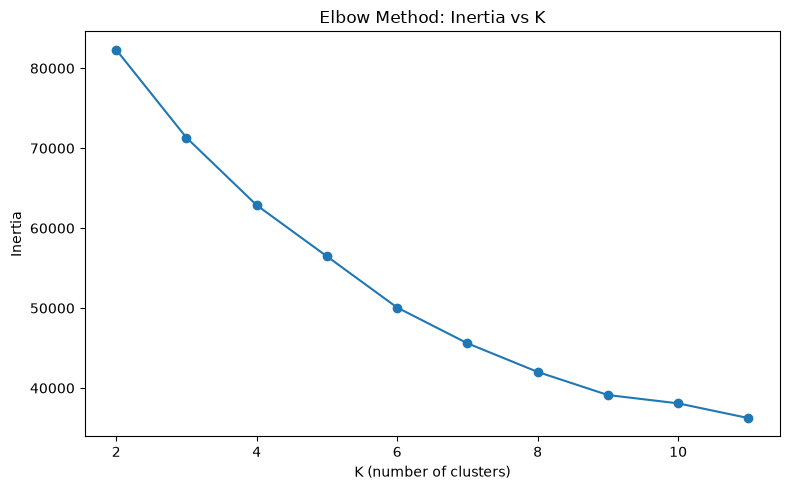

In [53]:
inertia_values = []
k_values = range(2, 12)

for k in k_values:
    km = KMeans(n_clusters=k , random_state=42 , n_init='auto')
    km.fit(scaled_X)
    inertia_values.append(km.inertia_)
    print(f"K={k:2d}  ->  inertia={km.inertia_:.1f}")


fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(k_values), inertia_values, marker="o")
ax.set_xlabel("K (number of clusters)")
ax.set_ylabel("Inertia")
ax.set_title("Elbow Method: Inertia vs K")
plt.tight_layout()
plt.savefig("../outputs/kmeans_elbow.png")
plt.show()

### optimal K value by Knee locator 

In [58]:
# 3. Automatically detect the elbow point

kl = KneeLocator(list(k_values), inertia_values, curve="convex", direction="decreasing")
optimal_k = kl.elbow
print(f"The optimal number of cluster through elow methhod is: {kl.elbow}")

The optimal number of cluster through elow methhod is: 6


### K-means Silhoute Score: 

K= 2  ->  silhouette=0.3346
K= 3  ->  silhouette=0.1971
K= 4  ->  silhouette=0.1919
K= 5  ->  silhouette=0.2122
K= 6  ->  silhouette=0.2353
K= 7  ->  silhouette=0.2437
K= 8  ->  silhouette=0.2417
K= 9  ->  silhouette=0.2439
K=10  ->  silhouette=0.2431
K=11  ->  silhouette=0.2319


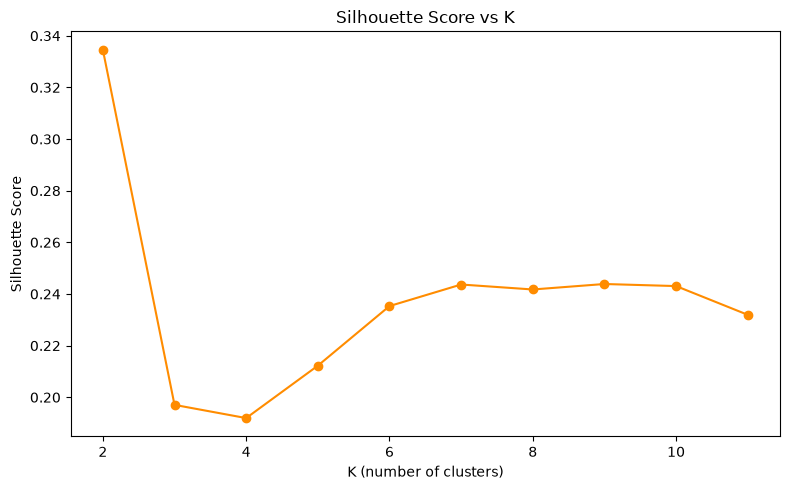

In [60]:
silhouette_scores = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(scaled_X)
    score = silhouette_score(scaled_X, labels)
    silhouette_scores.append(score)
    print(f"K={k:2d}  ->  silhouette={score:.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(k_values), silhouette_scores, marker="o", color="darkorange")
ax.set_xlabel("K (number of clusters)")
ax.set_ylabel("Silhouette Score")
ax.set_title("Silhouette Score vs K")
plt.tight_layout()
plt.savefig("../outputs/kmeans_silhouette.png")
plt.show()

## Finding and setting the optimal k

#### What is obbserved:
as from knee loacator , elbow method and silhoute score graphh it is observedd that k=6 is good enoughh that has less k value and better silhoute score beacuse k=2 have high silhoute score but it only 2 clusters dont capture ennough meanings .  In both scenioreis K=6 is optimal enough

In [61]:

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init="auto")
cluster_df["kmeans_cluster"] = kmeans_final.fit_predict(scaled_X)

print(f"Final K = {optimal_k}")
print(f"Inertia at this K: {kmeans_final.inertia_:.1f}")
print(f"Silhouette score at this K: {silhouette_score(scaled_X, cluster_df['kmeans_cluster']):.4f}")
print("\nCluster sizes:")
print(cluster_df["kmeans_cluster"].value_counts().sort_index())


Final K = 6
Inertia at this K: 50064.1
Silhouette score at this K: 0.2353

Cluster sizes:
kmeans_cluster
0     296
1    1222
2    2946
3     944
4     674
5    2868
Name: count, dtype: int64


## Making Cluster profiles:

In [62]:
cluster_profile = cluster_df.groupby("kmeans_cluster")[selected_f].mean().round(2)
cluster_profile["count"] = cluster_df["kmeans_cluster"].value_counts().sort_index()
cluster_profile.to_csv("../outputs/kmeans_cluster_profile.csv")
cluster_profile

,BALANCE,BALANCE_FREQUENCY,PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,PRC_FULL_PAYMENT,TENURE,count
kmeans_cluster,,,,,,,,,,,,
0,4051.68,0.98,8647.28,812.72,0.94,0.08,103.62,10275.84,8676.84,0.27,11.96,296
1,105.04,0.37,363.01,298.69,0.29,0.03,4.79,3799.63,1093.47,0.23,11.80,1222
2,945.11,0.97,1483.38,181.60,0.90,0.04,25.01,4598.99,1539.56,0.28,11.91,2946
3,5321.88,0.97,616.14,5040.60,0.33,0.46,8.91,8769.60,4109.08,0.03,11.67,944
4,859.50,0.80,433.73,1058.95,0.44,0.20,5.91,2459.23,591.93,0.16,7.33,674
5,1494.75,0.97,255.05,749.05,0.18,0.16,3.16,3157.03,974.06,0.02,11.88,2868


/var/folders/mc/x59j3q5924sby1mf7q1fdslm0000gq/T/ipykernel_16298/1975312753.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cluster_df, x="kmeans_cluster", y=feat, ax=axes[i], palette="Set2")
/var/folders/mc/x59j3q5924sby1mf7q1fdslm0000gq/T/ipykernel_16298/1975312753.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cluster_df, x="kmeans_cluster", y=feat, ax=axes[i], palette="Set2")
/var/folders/mc/x59j3q5924sby1mf7q1fdslm0000gq/T/ipykernel_16298/1975312753.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cluster_df, 

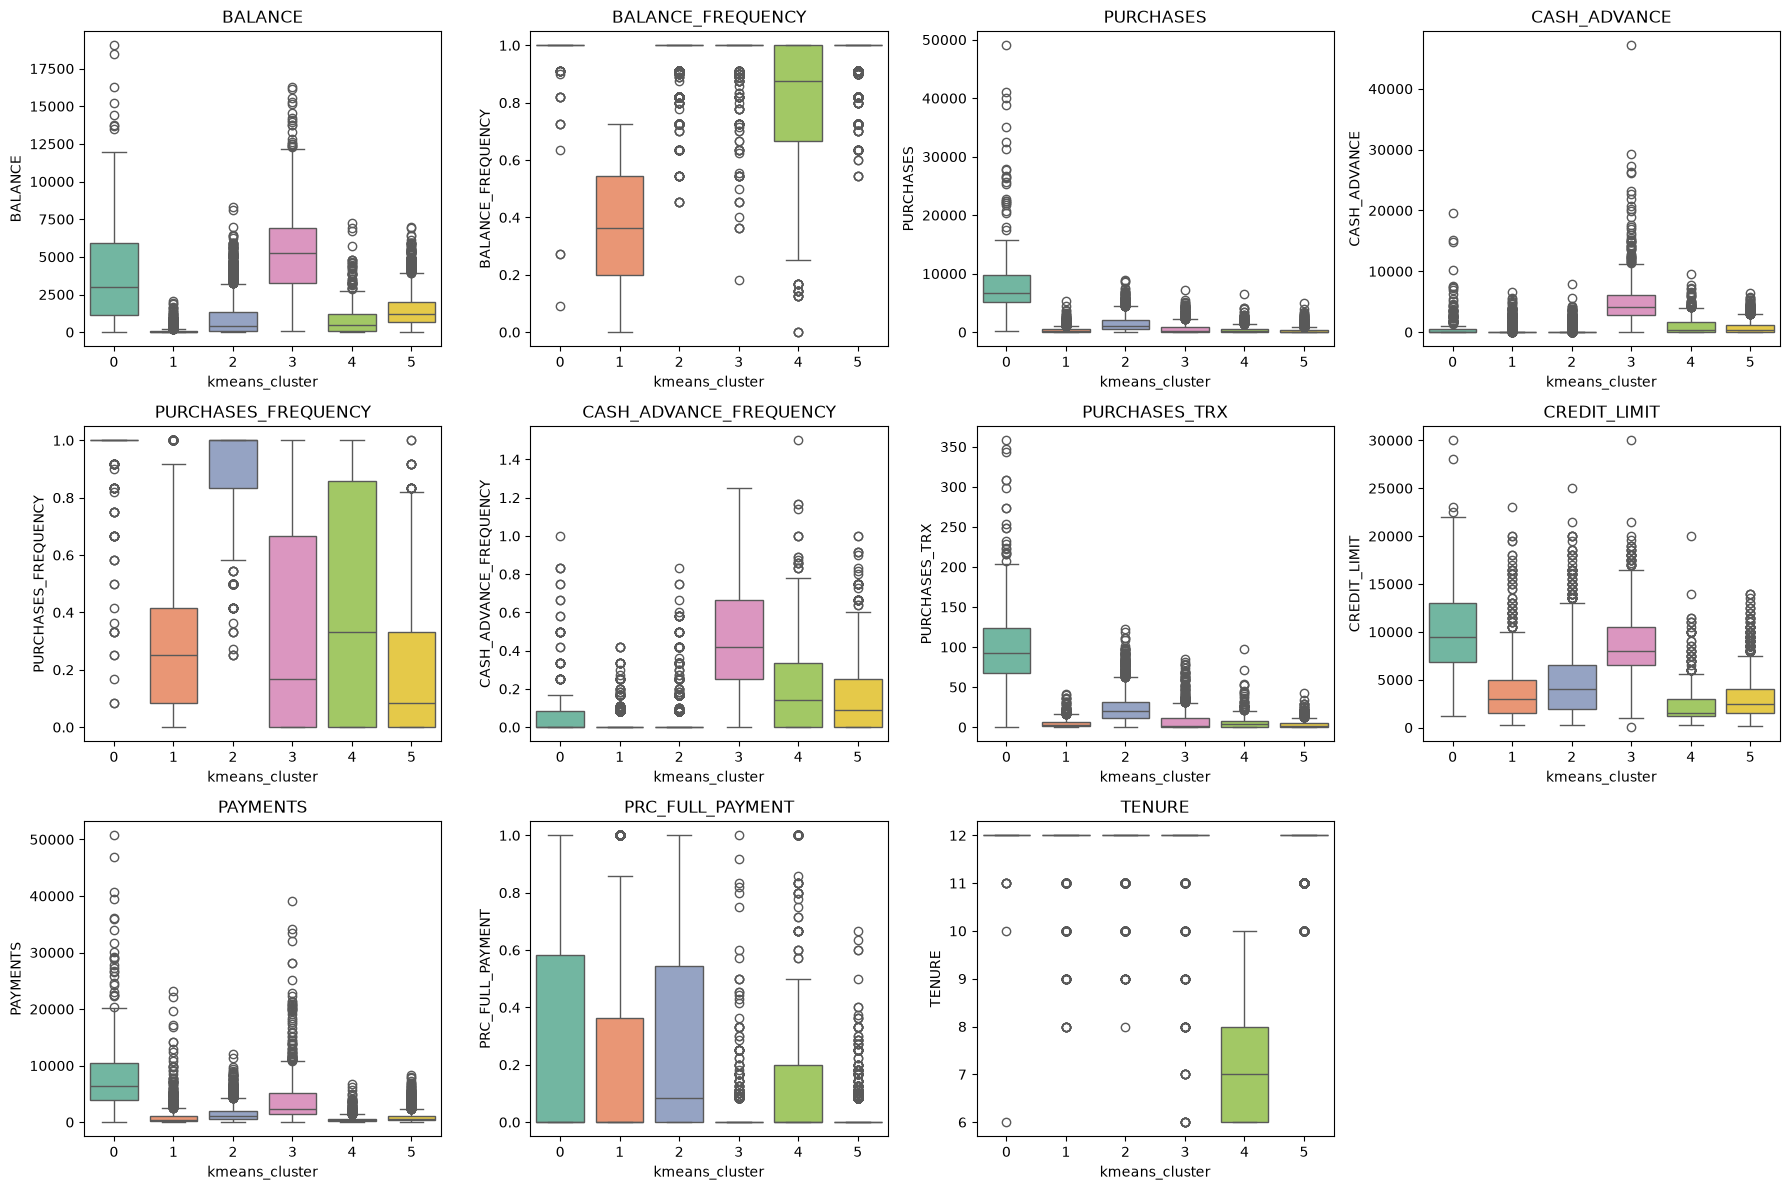

In [64]:

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, feat in enumerate(selected_f):
    sns.boxplot(data=cluster_df, x="kmeans_cluster", y=feat, ax=axes[i], palette="Set2")
    axes[i].set_title(feat)

# 2. Hide the remaining unused subplot (the 12th slot)
for j in range(len(selected_f), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig("../outputs/kmeans_cluster_boxplots.png")
plt.show()


## Descriptive stats of every cluster

In [67]:
cluster_stats = cluster_df.groupby("kmeans_cluster").describe().T
cluster_stats.to_csv("../outputs/kmeans_cluster_stats.csv")
cluster_stats

kmeans_cluster            0            1  ...            4            5
BALANCE count    296.000000  1222.000000  ...   674.000000  2868.000000
        mean    4051.682220   105.044793  ...   859.497073  1494.747100
        std     3567.962946   224.807948  ...  1081.885246  1146.278756
        min        4.382924     0.000000  ...     0.000000     0.488050
        25%     1119.307971     6.970297  ...    75.809042   683.826125
...                     ...          ...  ...          ...          ...
TENURE  min        6.000000     8.000000  ...     6.000000    10.000000
        25%       12.000000    12.000000  ...     6.000000    12.000000
        50%       12.000000    12.000000  ...     7.000000    12.000000
        75%       12.000000    12.000000  ...     8.000000    12.000000
        max       12.000000    12.000000  ...    10.000000    12.000000

[88 rows x 6 columns]

## DBSCAN

Dbscan does not assume the k before we dont have to pass no of k (clusters) . it works by growing clusters outward from dense neighborhoods of points — it keeps absorbing neighboring points as long as there are enough of them close together (min_samples within radius eps), and stops when the density runs out. 

IN. DBSCAN we have to pass two. parameters. 
1. eps (how close points must be to count as neighbors) radius
2. min_samples (how many neighbors a point needs to be considered part of a dense region)

### Multiple eps/min_samples configurations
In DBSCAN, any data point that is identified as an outlier or noise is assigned a label of -1. Real clusters get labels like 0, 1, 2, etc.

In [74]:
db_results = []

eps_range = [0.5, 0.8, 1.0, 1.5, 2.0] # testing various values
min_samp_range = [5, 8 , 11 , 15]

for eps in eps_range:
    for min_sample in min_samp_range:
        db_scan  = DBSCAN(eps=eps , min_samples=min_sample)
        labels = db_scan.fit_predict(scaled_X)

        #now we have to know actual clusters and noise 

        #actual clusters  e.g {-1 , 0 } here. actual cluster is "0" means only 1 cluster not 2 so we have to count actual one
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0) 

        # total noisy points
        noise_points = int((labels == -1).sum())

        #noise percentange
        noise_perct = noise_points / len(labels) * 100


        # Silhouette score with more than 2 clusters without noise
        if n_clusters >= 2:
            mask = labels != -1
            sil = silhouette_score(scaled_X[mask], labels[mask]) if mask.sum() > 1 else np.nan
        else:
            sil = np.nan

        db_results.append({
            "eps": eps, "min_samples": min_sample,
            "n_clusters": n_clusters, "noise_points": noise_points,
            "noise_perct": round(noise_perct, 1), "silhouette": sil,
        })

dbscan_results_df = pd.DataFrame(db_results)
dbscan_results_df.to_csv("../outputs/dbscan_grid_search.csv", index=False)
dbscan_results_df








,eps,min_samples,n_clusters,noise_points,noise_perct,silhouette
0,0.5,5,27,4804,53.7,-0.421997
1,0.5,8,12,5298,59.2,-0.365096
2,0.5,11,8,5774,64.5,-0.126824
3,0.5,15,5,6119,68.4,0.196419
4,0.8,5,21,2381,26.6,-0.292503
5,0.8,8,10,2804,31.3,-0.123202
6,0.8,11,8,3077,34.4,0.105297
7,0.8,15,4,3343,37.4,0.285868
8,1.0,5,9,1403,15.7,0.056822
9,1.0,8,3,1631,18.2,0.219675


so from aove table we have to select eps and min samples with moederate clusters less nnoise and healthy silhoute score . not very less eps that creates too much tiny clusters and not so large eps that will make all points fallen into one cluster . so from aove table 
1. eps = 1.5 , min_sample = 5 , silhoute = 0.297730 is better with good score andd cluster numbers

## Final DBSCAN

In [82]:
optimal_eps = 1.5
optimal_min_sample = 5

dbscan_final = DBSCAN(eps=optimal_eps  , min_samples=optimal_min_sample)
cluster_df["dbscan_clusters"] = dbscan_final.fit_predict(scaled_X)

n_clusters_final = len(set(cluster_df["dbscan_clusters"])) - (1 if -1 in cluster_df["dbscan_clusters"].values else 0)
n_noise_final = int((cluster_df["dbscan_clusters"] == -1).sum())

print(f"Final DBSCAN config: eps={optimal_eps}, min_samples={optimal_min_sample}")
print(f"Clusters found: {n_clusters_final}")
print(f"Points labeled as noise: {n_noise_final} ({n_noise_final / len(cluster_df) * 100:.1f}% of all customers)")
print("\nCluster sizes (label -1 = noise):")
print(cluster_df["dbscan_clusters"].value_counts().sort_index())


Final DBSCAN config: eps=1.5, min_samples=5
Clusters found: 2
Points labeled as noise: 489 (5.5% of all customers)

Cluster sizes (label -1 = noise):
dbscan_clusters
-1     489
 0    8457
 1       4
Name: count, dtype: int64


Customers labeled as noise (-1) by DBSCAN should be analyzed, not discarded, because they reveal unique consumer behaviors. Unlike K-Means, which masks outliers by forcing them into the nearest available cluster, DBSCAN preserves their individuality. These anomalous rows frequently highlight critical operational segments: extreme high-spenders, erratic accounts, or novel behavioral patterns that would otherwise be hidden inside a generalized group.

In [83]:
# A quick look at who actually got flagged as noise, compared to the overall population
noise_profile = cluster_df[cluster_df["dbscan_clusters"] == -1][selected_f].mean().round(2)
overall_profile = cluster_df[selected_f].mean().round(2)

comparison = pd.DataFrame({"noise_mean": noise_profile, "overall_mean": overall_profile})
comparison["ratio"] = (comparison["noise_mean"] / comparison["overall_mean"]).round(2)
comparison


,noise_mean,overall_mean,ratio
BALANCE,4252.38,1564.47,2.72
BALANCE_FREQUENCY,0.89,0.88,1.01
PURCHASES,4561.82,1003.20,4.55
CASH_ADVANCE,4291.23,978.87,4.38
PURCHASES_FREQUENCY,0.62,0.49,1.27
CASH_ADVANCE_FREQUENCY,0.32,0.14,2.29
PURCHASES_TRX,49.54,14.71,3.37
CREDIT_LIMIT,10247.34,4494.28,2.28
PAYMENTS,8540.66,1733.14,4.93
PRC_FULL_PAYMENT,0.21,0.15,1.40


so as from above table customers with more high balance , purchases, cash advances, creddit limit , payemnts are considered as noise means those who spend more andd have. hhigh balances are. unique customers


## PCA : Principal Component Analysis - reducing to two dimensions (Dimensionality reduction)

I have 11 features and i cannot plot them all. PCA translates our 11-dimensional dataset into a 2D snapshot optimized for visualization. It creates new axes (principal components) sorted by how much data variance they capture, meaning the first two dimensions provide the best possible flat approximation of our original data structure. For PCA to look at the data holistically, the features must remain scaled. If raw values were used, a high-magnitude feature like CREDIT_LIMIT and some other columns would completely distort the variance calculations, causing the first component to mirror that single variable instead of capturing a meaningful blend of overall consumer behavior.

What is Explained Variance?

Definition: 
It tells you the exact percentage of total information that a single principal component (PC) holds.

Order of importance: PCA ranks components from highest to lowest. The first component (PC1) always has the highest explained variance because it captures the strongest pattern in the data.

Calculation: It equals the eigenvalue of a specific component divided by the sum of all eigenvalues.

What is Cumulative Variance?

Definition: It is the running sum of the explained variance ratios from the first component up to your current component.

Total information: Adding the explained variance of all components together gives 100% (or 1.0) of the original dataset's variance.

Tracking progress: If PC1 explains 40% and PC2 explains 30%, the cumulative variance after two components is 70%


## Pca for all 11 features

PC1: explains 27.19% individually, 27.19% cumulative
PC2: explains 23.28% individually, 50.46% cumulative
PC3: explains 10.98% individually, 61.44% cumulative
PC4: explains  9.29% individually, 70.73% cumulative
PC5: explains  7.49% individually, 78.21% cumulative
PC6: explains  6.52% individually, 84.74% cumulative
PC7: explains  4.73% individually, 89.47% cumulative
PC8: explains  3.87% individually, 93.34% cumulative
PC9: explains  2.75% individually, 96.09% cumulative
PC10: explains  2.37% individually, 98.46% cumulative
PC11: explains  1.54% individually, 100.00% cumulative


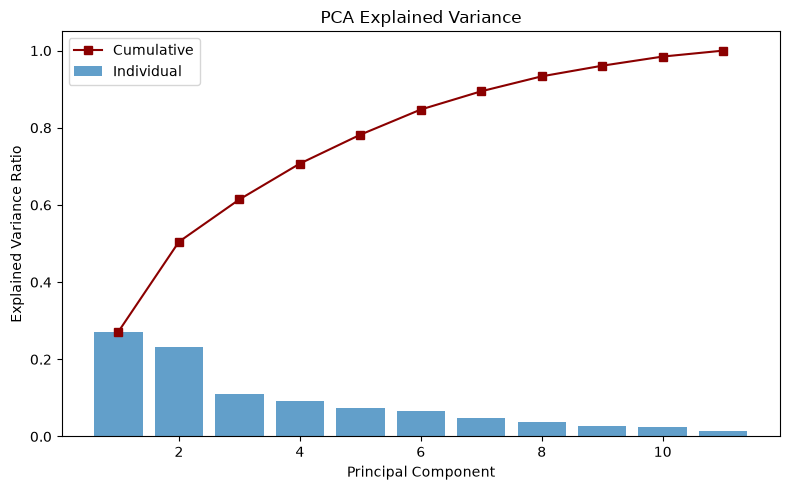

In [88]:
pca_full = PCA(random_state=42)
pca_full.fit(scaled_X)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

for i, (ev, cv) in enumerate(zip(explained_var, cumulative_var), start=1):
    print(f"PC{i}: explains {ev*100:5.2f}% individually, {cv*100:5.2f}% cumulative")

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(range(1, len(explained_var) + 1), explained_var, alpha=0.7, label="Individual")
ax.plot(range(1, len(explained_var) + 1), cumulative_var, marker="s", color="darkred", label="Cumulative")
ax.set_xlabel("Principal Component")
ax.set_ylabel("Explained Variance Ratio")
ax.set_title("PCA Explained Variance")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/pca_explained_variance.png")
plt.show()


In [89]:
pca_two = PCA(n_components=2 , random_state=42)
pca_X = pca_two.fit_transform(scaled_X)

pc1_var, pc2_var = pca_two.explained_variance_ratio_
print(f"PC1 explains {pc1_var*100:.2f}% of variance")
print(f"PC2 explains {pc2_var*100:.2f}% of variance")
print(f"Together, these 2 components explain {(pc1_var + pc2_var)*100:.2f}% of the original 11 feature variance")

PC1 explains 27.19% of variance
PC2 explains 23.28% of variance
Together, these 2 components explain 50.46% of the original 11 feature variance


## Kmeans cluster in PCA dimension

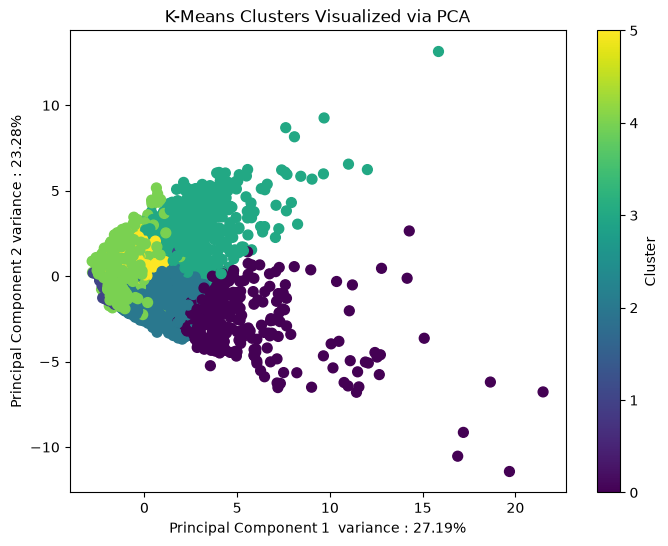

In [91]:
plt.figure(figsize=(8, 6))
plt.scatter(pca_X[:, 0], pca_X[:, 1], c=cluster_df["kmeans_cluster"], cmap='viridis', s=50)
plt.title('K-Means Clusters Visualized via PCA')
plt.xlabel(f'Principal Component 1  variance : {pc1_var*100:.2f}%')
plt.ylabel(f'Principal Component 2 variance : {pc2_var*100:.2f}%')
plt.colorbar(label='Cluster')
plt.savefig("../outputs/kmeans_in_pca_dimension.png")
plt.show()

## DBscan in PCA Dimension

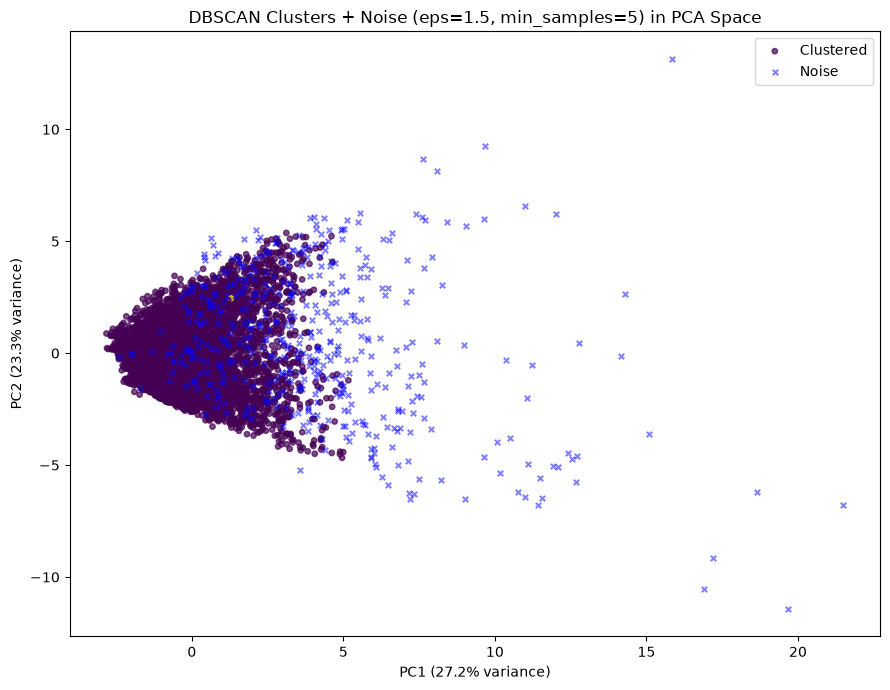

In [98]:
fig, ax = plt.subplots(figsize=(9, 7))

noise_mask = cluster_df["dbscan_clusters"] == -1
cluster_mask = ~noise_mask

scatter = ax.scatter(pca_X[cluster_mask, 0], pca_X[cluster_mask, 1],
                      c=cluster_df.loc[cluster_mask, "dbscan_clusters"],
                      cmap="viridis", s=15, alpha=0.7, label="Clustered")


ax.scatter(pca_X[noise_mask, 0], pca_X[noise_mask, 1],
           c="blue", s=15, alpha=0.5, marker="x", label="Noise")

ax.set_xlabel(f"PC1 ({pc1_var*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pc2_var*100:.1f}% variance)")
ax.set_title(f"DBSCAN Clusters + Noise (eps={optimal_eps}, min_samples={optimal_min_sample}) in PCA Space")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/dbscan_pca_scatter.png")
plt.show()


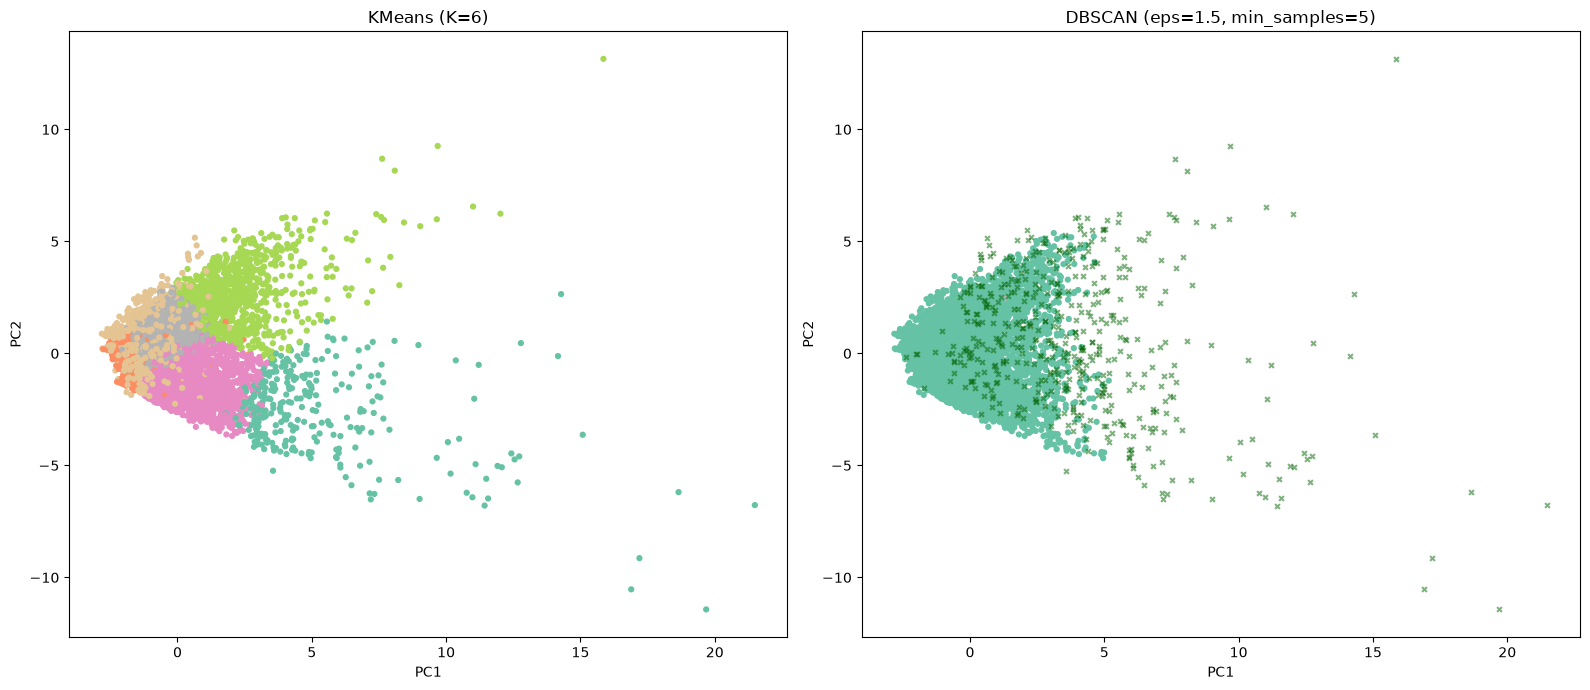

In [103]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].scatter(pca_X[:,0] , pca_X[:,1] , c=cluster_df["kmeans_cluster"] , cmap="Set2", s=12,)
axes[0].set_title(f"KMeans (K={optimal_k})")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

axes[1].scatter(pca_X[cluster_mask , 0], pca_X[cluster_mask , 1] , c= cluster_df.loc[cluster_mask , "dbscan_clusters"] , cmap="Set2", s=12,)
axes[1].scatter(pca_X[noise_mask, 0], pca_X[noise_mask, 1], c="darkgreen", s=12, alpha=0.5, marker="x")
axes[1].set_title(f"DBSCAN (eps={optimal_eps}, min_samples={optimal_min_sample})")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

plt.tight_layout()
plt.savefig("../outputs/kmeans_vs_dbscan_pca.png")
plt.show()


